# Industrial Sensor Alarm — ML Models

| # | Model | Task | Algorithm | Key change |
|---|-------|------|-----------|------------|
| 1 | Anomaly Detector | Unsupervised score | Isolation Forest | Fit train-only |
| 2 | Soft Alarm | Binary alarm probability | LR + Calibrated RF blend | Smooth [0,1], no 0%/100% |
| 3 | Regime Classifier | Normal / Transition / Alarm | Logistic Multinomial | Calibrated 3-class proba |
| 4 | Process Correlation | Sensor PCA | PCA | — |
| 5 | Deviation Forecaster | LIC31002 deviation t+1h | Ridge | Replaces leaked target |
| 6–8 | Horizon Forecasters | Anomaly P(t+h) | Calibrated XGBoost | Isotonic calibration |

**Key changes from prior version:**
- Loaded from `data_drop/labeled_dataset.csv` — no intra-hour `_max`/`_min`/`_roll3h` leakage
- Deviations computed on-the-fly from SP − PV (available at inference time from PLC)
- `LT31013` dropped (sensor saturated at 105%, constant signal)
- Tree models wrapped in `CalibratedClassifierCV(isotonic)` — eliminates 0%/100% outputs
- Soft alarm = LR sigmoid + calibrated RF blend, smoothed with EWM (α=0.3)
- Brier score tracked for all classifiers to measure probability calibration quality
- Window trend (last − first) replaces window max in forecasters (trend is more informative)

## Setup

In [ ]:
# !pip install xgboost shap mlflow

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
import seaborn as sns
import joblib
import os
import warnings
warnings.filterwarnings('ignore')

import mlflow
import mlflow.sklearn
import mlflow.xgboost
from mlflow.tracking import MlflowClient

from sklearn.ensemble import IsolationForest, RandomForestClassifier, GradientBoostingClassifier
from sklearn.linear_model import LogisticRegression, Ridge
from sklearn.calibration import CalibratedClassifierCV, calibration_curve
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.model_selection import TimeSeriesSplit
from sklearn.metrics import (
    classification_report, confusion_matrix, accuracy_score,
    roc_auc_score, f1_score, precision_score, recall_score,
    mean_absolute_error, r2_score, brier_score_loss,
    average_precision_score,
)

try:
    from xgboost import XGBClassifier
    XGB_AVAILABLE = True
    print('XGBoost available ✅')
except ImportError:
    XGB_AVAILABLE = False
    print('XGBoost not found — using GradientBoosting')

try:
    import shap
    SHAP_AVAILABLE = True
    print('SHAP available ✅')
except ImportError:
    SHAP_AVAILABLE = False

os.makedirs('models', exist_ok=True)
os.makedirs('eda_plots', exist_ok=True)
plt.rcParams['figure.dpi'] = 120
sns.set_style('whitegrid')

MLFLOW_URI = os.getenv('MLFLOW_TRACKING_URI', 'http://localhost:5000')
EXPERIMENT  = 'plant_alarm_training'
mlflow.set_tracking_uri(MLFLOW_URI)
mlflow.set_experiment(EXPERIMENT)
client = MlflowClient(MLFLOW_URI)
print(f'MLflow URI  : {MLFLOW_URI}')
print(f'Experiment  : {EXPERIMENT}')
print('Setup complete!')

## Load & Label Data

In [ ]:
df = pd.read_csv('data_drop/labeled_dataset.csv',
                 index_col='timestamp', parse_dates=True)

# Drop empty artifact columns left over from prior CSV export
df = df.loc[:, ~df.columns.str.startswith('Unnamed')]

# Instantaneous SP-PV deviations — derived from columns always present in the PLC
# snapshot, so these are valid at inference time with no intra-hour leakage.
df['LIC31012_deviation'] = df['LIC31012_SP'] - df['LIC31012_PV']
df['LIC31002_deviation'] = df['LIC31002_SP'] - df['LIC31002_PV']
df['FIC31011_deviation'] = df['FIC31011_SP'] - df['FIC31011_PV']

print(f'Dataset : {df.shape}')
print(f'Period  : {df.index[0]} → {df.index[-1]}')
print(f'Anomaly rate : {df["anomaly_label"].mean()*100:.1f}%')
print(f'Regime dist  : {df["regime"].value_counts().sort_index().to_dict()}')

labeled_ds = mlflow.data.from_pandas(df, name='plant_alarm_labeled',
                                      source='data_drop/labeled_dataset.csv')
print('\nData loaded.')

## Feature Sets

In [ ]:
# LT31013 excluded — saturated at ~105% throughout; zero discriminative signal.
# SP columns excluded — operator setpoints are not process state; SP-PV deviations
# (computed above) capture the same intent-vs-reality gap without redundancy.
POINT_FEATURES = [
    # Process sensor readings
    'TE301020', 'PDT31008', 'PDT31001', 'PDT31007',
    'FQ31050', 'LT301031',
    # Controller PV (measured) and OP (valve position)
    'LIC31012_PV', 'LIC31002_PV', 'FIC31011_PV',
    'LIC31012_OP', 'LIC31002_OP', 'FIC31011_OP',
    # Instantaneous setpoint deviations (SP − PV)
    'LIC31012_deviation', 'LIC31002_deviation', 'FIC31011_deviation',
    # Operational time features (shift / weekday patterns)
    'hour_of_day', 'day_of_week',
]

X        = df[POINT_FEATURES].values
y_binary = df['anomaly_label'].values
y_regime = df['regime'].values

scaler   = StandardScaler()
X_scaled = scaler.fit_transform(X)

split_idx = int(len(df) * 0.75)
X_train, X_test = X_scaled[:split_idx], X_scaled[split_idx:]
y_train_b, y_test_b = y_binary[:split_idx], y_binary[split_idx:]
y_train_r, y_test_r = y_regime[:split_idx], y_regime[split_idx:]

print(f'Features : {len(POINT_FEATURES)}')
print(f'Train    : {len(X_train)} rows  ({df.index[0].date()} → {df.index[split_idx-1].date()})')
print(f'Test     : {len(X_test)} rows  ({df.index[split_idx].date()} → {df.index[-1].date()})')

## Model 1: Isolation Forest — Anomaly Detection
**Unsupervised** — no labels needed. Detects anomalous sensor patterns.


In [ ]:
iso_forest = IsolationForest(
    n_estimators=300,
    contamination=float(y_train_b.mean()),   # calibrated to training base rate only
    max_samples=min(256, len(X_train)),
    random_state=42,
    n_jobs=-1,
)
iso_forest.fit(X_train)   # train-only — avoids look-ahead contamination from test anomalies

raw_scores     = iso_forest.score_samples(X_scaled)
if_scores_norm = 1.0 - (raw_scores - raw_scores.min()) / (raw_scores.max() - raw_scores.min())
if_pred        = (if_scores_norm > 0.5).astype(int)

df['if_anomaly_score'] = if_scores_norm
df['if_anomaly_pred']  = if_pred

if_auc   = roc_auc_score(y_binary, if_scores_norm)
if_f1    = f1_score(y_binary, if_pred)
if_brier = brier_score_loss(y_binary, if_scores_norm)
print(f'Isolation Forest — AUC={if_auc:.3f}  F1={if_f1:.3f}  Brier={if_brier:.3f}')

with mlflow.start_run(run_name='isolation_forest') as run:
    mlflow.log_input(labeled_ds, context='training')
    mlflow.log_params({
        'model_type':    'isolation_forest',
        'n_estimators':  300,
        'contamination': round(float(y_train_b.mean()), 4),
        'fit_on':        'train_only',
        'feature_count': len(POINT_FEATURES),
    })
    mlflow.log_metrics({'roc_auc': if_auc, 'f1': if_f1, 'brier_score': if_brier})
    mlflow.sklearn.log_model(iso_forest, artifact_path='model',
                             registered_model_name='plant_alarm_isolation_forest')
    joblib.dump(scaler, 'models/scaler.joblib')
    mlflow.log_artifact('models/scaler.joblib', artifact_path='model')
    IF_RUN_ID = run.info.run_id

joblib.dump(iso_forest, 'models/isolation_forest.joblib')
print(f'MLflow run: {IF_RUN_ID[:8]}...')

### Anomaly Score Over Time

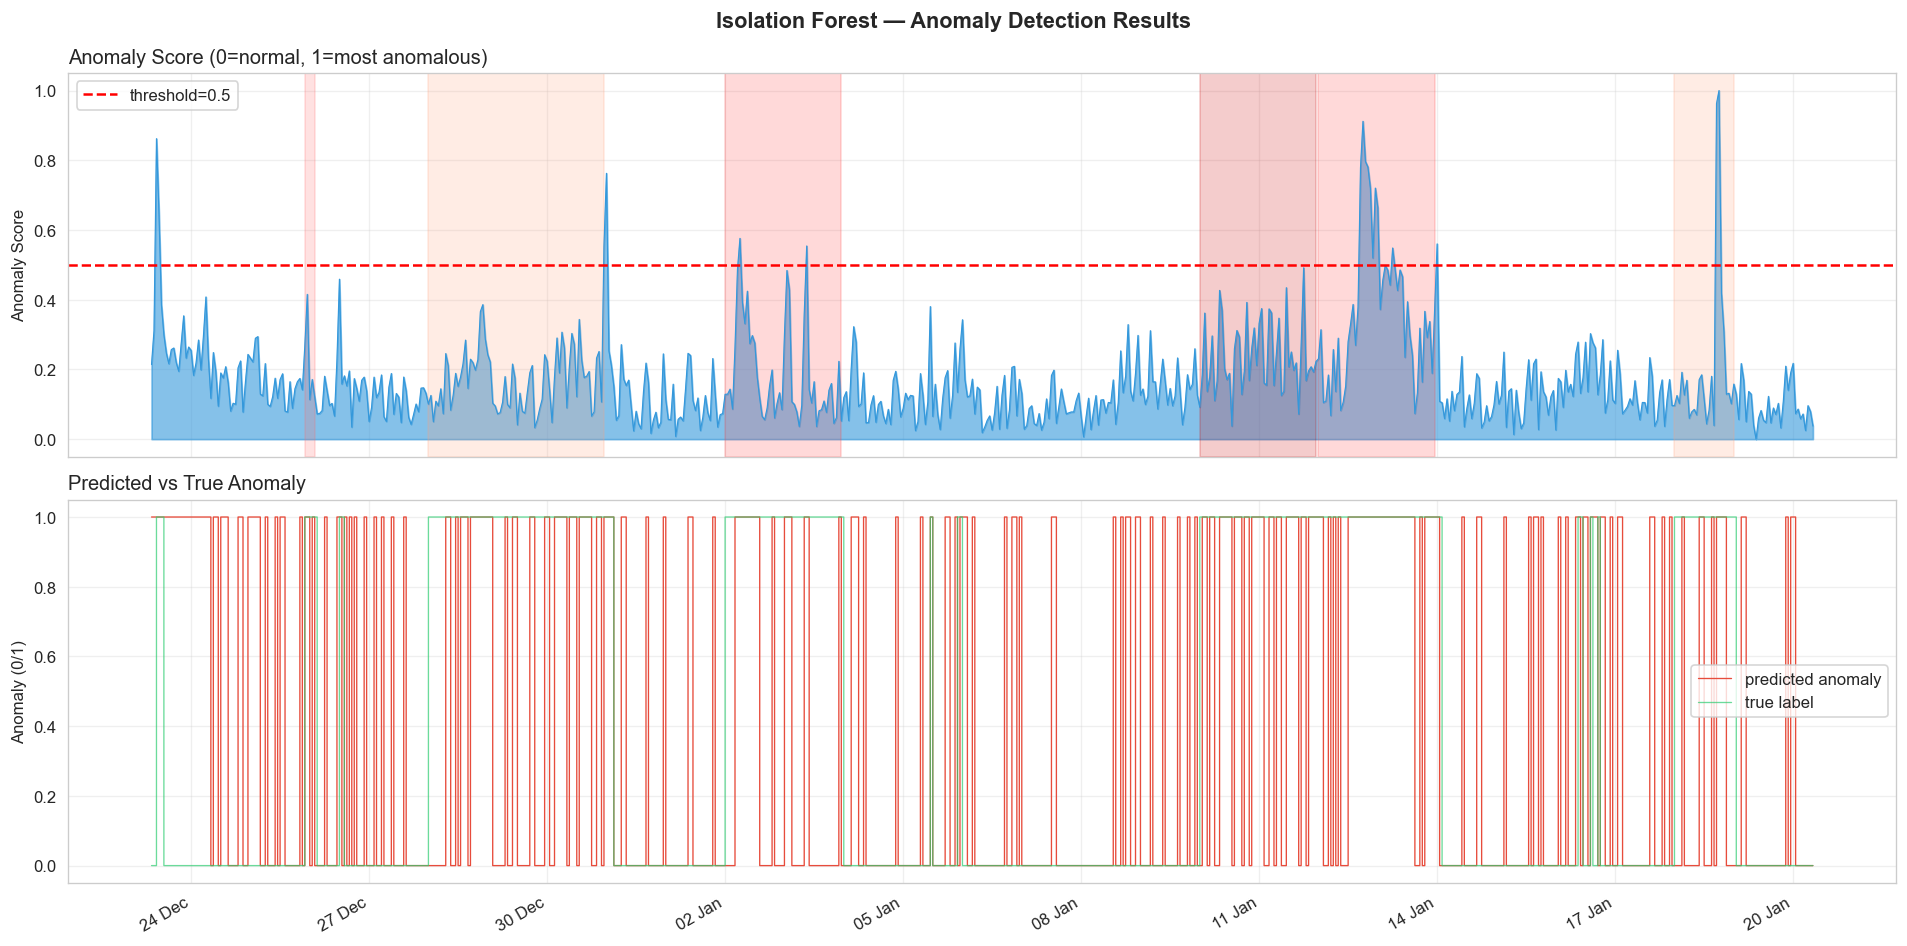

In [8]:
ANOMALY_PERIODS_COLORS = [
    ('2014-12-25 22:00', '2014-12-26 02:00', '#FF6B6B'),
    ('2014-12-28 00:00', '2014-12-30 23:00', '#FFA07A'),
    ('2015-01-02 00:00', '2015-01-03 23:00', '#FF4444'),
    ('2015-01-10 00:00', '2015-01-11 23:00', '#CC0000'),
    ('2015-01-12 00:00', '2015-01-13 23:00', '#FF4444'),
    ('2015-01-18 00:00', '2015-01-19 00:00', '#FFA07A'),
]

fig, axes = plt.subplots(2, 1, figsize=(16, 8), sharex=True)
fig.suptitle('Isolation Forest — Anomaly Detection Results', fontsize=13, fontweight='bold')

ax = axes[0]
ax.fill_between(df.index, 0, df['if_anomaly_score'], alpha=0.6, color='#3498DB')
ax.plot(df.index, df['if_anomaly_score'], color='#3498DB', linewidth=0.7)
ax.axhline(0.5, color='red', linewidth=1.5, linestyle='--', label='threshold=0.5')
for s, e, c in ANOMALY_PERIODS_COLORS:
    ax.axvspan(pd.Timestamp(s), pd.Timestamp(e), alpha=0.2, color=c)
ax.set_ylabel('Anomaly Score')
ax.set_title('Anomaly Score (0=normal, 1=most anomalous)', loc='left')
ax.legend()
ax.grid(True, alpha=0.3)

ax = axes[1]
ax.plot(df.index, df['if_anomaly_pred'], color='#E74C3C', linewidth=0.8,
        drawstyle='steps-post', label='predicted anomaly')
ax.plot(df.index, df['anomaly_label'], color='#2ECC71', linewidth=0.8,
        drawstyle='steps-post', alpha=0.7, label='true label')
ax.set_ylabel('Anomaly (0/1)')
ax.set_title('Predicted vs True Anomaly', loc='left')
ax.legend()
ax.grid(True, alpha=0.3)

axes[-1].xaxis.set_major_formatter(mdates.DateFormatter('%d %b'))
axes[-1].xaxis.set_major_locator(mdates.DayLocator(interval=3))
plt.setp(axes[-1].xaxis.get_majorticklabels(), rotation=30, ha='right')
plt.tight_layout()
plt.savefig('eda_plots/07_isolation_forest_results.png', dpi=150, bbox_inches='tight')
plt.show()

## Model 2: Soft Alarm Probability — LR + Calibrated RF Blend

**Why tree models give 0% / 100%:** With 500 training samples and `max_depth=5`, leaves can contain only 1–2 samples and return extreme empirical probabilities. Two fixes are applied:

1. **Logistic Regression** (C=0.5): decision boundary is a linear sigmoid — probability is inherently smooth and bounded away from 0 and 1.
2. **Random Forest + isotonic calibration** via `CalibratedClassifierCV`: leaf proportions are rescaled against held-out time-series folds, removing the extreme-probability bias.
3. **Probability blend**: averaging the two independently calibrated models further smooths the surface.
4. **EWM smoothing** (α=0.3 ≈ 3-step memory): suppresses alarm flicker from single noisy readings.

In [ ]:
lr_alarm = LogisticRegression(
    C=0.5, solver='lbfgs', max_iter=2000, class_weight='balanced', random_state=42,
)
lr_alarm.fit(X_train, y_train_b)

rf_base = RandomForestClassifier(
    n_estimators=300, max_depth=5, min_samples_leaf=8,
    class_weight='balanced', random_state=42, n_jobs=-1,
)
rf_cal = CalibratedClassifierCV(rf_base, method='isotonic', cv=TimeSeriesSplit(n_splits=3))
rf_cal.fit(X_train, y_train_b)

lr_p_test = lr_alarm.predict_proba(X_test)[:, 1]
rf_p_test = rf_cal.predict_proba(X_test)[:, 1]
blend_test = 0.5 * lr_p_test + 0.5 * rf_p_test

lr_p_all  = lr_alarm.predict_proba(X_scaled)[:, 1]
rf_p_all  = rf_cal.predict_proba(X_scaled)[:, 1]
blend_all = 0.5 * lr_p_all + 0.5 * rf_p_all

# EWM smoothing: reduces alarm flicker from single noisy readings
alarm_smooth = pd.Series(blend_all, index=df.index).ewm(alpha=0.3).mean().values
df['alarm_prob_raw']    = blend_all
df['alarm_prob_smooth'] = alarm_smooth
df['alarm_pred']        = (blend_all > 0.5).astype(int)

print('Test-set metrics:')
for name, p in [('LR', lr_p_test), ('RF+Cal', rf_p_test), ('Blend', blend_test)]:
    auc_v   = roc_auc_score(y_test_b, p)
    f1_v    = f1_score(y_test_b, (p > 0.5).astype(int))
    brier_v = brier_score_loss(y_test_b, p)
    print(f'  {name:<10} AUC={auc_v:.3f}  F1={f1_v:.3f}  Brier={brier_v:.3f}')

alarm_auc   = roc_auc_score(y_test_b, blend_test)
alarm_f1    = f1_score(y_test_b, (blend_test > 0.5).astype(int))
alarm_brier = brier_score_loss(y_test_b, blend_test)

with mlflow.start_run(run_name='soft_alarm_blend') as run:
    mlflow.log_input(labeled_ds, context='training')
    mlflow.log_params({
        'model_type':      'lr_rf_isotonic_blend',
        'lr_C':            0.5,
        'rf_n_estimators': 300,
        'rf_max_depth':    5,
        'rf_min_leaf':     8,
        'calibration':     'isotonic',
        'blend_weights':   '0.5_lr_0.5_rf',
        'ewm_alpha':       0.3,
        'feature_count':   len(POINT_FEATURES),
    })
    mlflow.log_metrics({'roc_auc': alarm_auc, 'f1': alarm_f1, 'brier_score': alarm_brier})
    mlflow.sklearn.log_model(lr_alarm, artifact_path='lr_model',
                             registered_model_name='plant_alarm_lr_soft_alarm')
    mlflow.sklearn.log_model(rf_cal,   artifact_path='rf_model',
                             registered_model_name='plant_alarm_rf_soft_alarm')
    ALARM_RUN_ID = run.info.run_id

joblib.dump(lr_alarm, 'models/lr_soft_alarm.joblib')
joblib.dump(rf_cal,   'models/rf_soft_alarm.joblib')
print(f'\nMLflow run: {ALARM_RUN_ID[:8]}...')

# ── Calibration curves + time-series view ─────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(16, 5))
fig.suptitle('Model 2 — Soft Alarm Probability', fontweight='bold')

ax = axes[0]
for name, probs in [('Isolation Forest', if_scores_norm),
                    ('LR', lr_p_all), ('RF+Cal', rf_p_all),
                    ('Blend+EWM', alarm_smooth)]:
    frac, mean_p = calibration_curve(y_binary, probs, n_bins=8)
    ax.plot(mean_p, frac, 's-', label=name, markersize=5)
ax.plot([0, 1], [0, 1], 'k--', linewidth=1, label='Perfect')
ax.set_xlabel('Mean predicted probability'); ax.set_ylabel('Fraction positives')
ax.set_title('Calibration Curves'); ax.legend(fontsize=9); ax.grid(True, alpha=0.3)

ax = axes[1]
test_idx = df.index[split_idx:]
ax.fill_between(test_idx, 0, df.loc[test_idx, 'alarm_prob_smooth'],
                alpha=0.4, color='#E74C3C', label='Alarm prob (EWM smoothed)')
ax.plot(test_idx, df.loc[test_idx, 'alarm_prob_raw'],
        color='#E74C3C', linewidth=0.5, alpha=0.5, label='Raw blend')
ax.step(test_idx, y_test_b, color='#2ECC71', linewidth=1.2, where='post', label='True label')
ax.axhline(0.5, color='gray', linewidth=0.8, linestyle='--', alpha=0.7)
ax.set_ylabel('Probability')
ax.set_title(f'Test Set — Alarm Prob   AUC={alarm_auc:.3f}  Brier={alarm_brier:.3f}')
ax.legend(fontsize=9); ax.grid(True, alpha=0.3)
ax.xaxis.set_major_formatter(mdates.DateFormatter('%d %b'))
plt.setp(ax.xaxis.get_majorticklabels(), rotation=30, ha='right')

plt.tight_layout()
plt.savefig('eda_plots/08_soft_alarm_probability.png', dpi=150, bbox_inches='tight')
plt.show()

## Model 4: PCA — Process Correlation Analysis
Shows how sensors relate to each other and which linear combinations explain process variance.

In [ ]:
lr_regime = LogisticRegression(
    C=1.0, multi_class='multinomial', solver='lbfgs',
    max_iter=2000, class_weight='balanced', random_state=42,
)
lr_regime.fit(X_train, y_train_r)

y_pred_r     = lr_regime.predict(X_test)
regime_probs = lr_regime.predict_proba(X_scaled)

df['regime_pred']  = lr_regime.predict(X_scaled)
df['p_normal']     = regime_probs[:, 0]
df['p_transition'] = regime_probs[:, 1]
df['p_alarm']      = regime_probs[:, 2]

clf_acc = accuracy_score(y_test_r, y_pred_r)
print(f'Regime Classifier — Accuracy={clf_acc:.3f}')
print(classification_report(y_test_r, y_pred_r,
                             target_names=['Normal', 'Transition', 'Alarm'],
                             digits=3, zero_division=0))

with mlflow.start_run(run_name='regime_classifier') as run:
    mlflow.log_input(labeled_ds, context='training')
    mlflow.log_params({
        'model_type':    'logistic_multinomial',
        'C':             1.0,
        'class_weight':  'balanced',
        'feature_count': len(POINT_FEATURES),
    })
    mlflow.log_metrics({
        'accuracy': clf_acc,
        'f1_alarm': float(f1_score(y_test_r, y_pred_r, labels=[2], average='micro')),
    })
    mlflow.sklearn.log_model(lr_regime, artifact_path='model',
                             registered_model_name='plant_alarm_regime_classifier')
    CLF_RUN_ID = run.info.run_id

joblib.dump(lr_regime, 'models/regime_classifier.joblib')

# ── Confusion matrix + regime probability over time ───────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(15, 5))
fig.suptitle('Model 3 — Regime Classification (Logistic Multinomial)', fontweight='bold')

cm = confusion_matrix(y_test_r, y_pred_r)
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', ax=axes[0],
            xticklabels=['Normal', 'Transition', 'Alarm'],
            yticklabels=['Normal', 'Transition', 'Alarm'])
axes[0].set_title('Confusion Matrix'); axes[0].set_ylabel('True'); axes[0].set_xlabel('Predicted')

ax = axes[1]
test_idx = df.index[split_idx:]
ax.fill_between(test_idx, 0, df.loc[test_idx, 'p_alarm'],      alpha=0.5, color='#E74C3C', label='P(Alarm)')
ax.fill_between(test_idx, 0, df.loc[test_idx, 'p_transition'], alpha=0.5, color='#F39C12', label='P(Transition)')
ax.fill_between(test_idx, 0, df.loc[test_idx, 'p_normal'],     alpha=0.25, color='#2ECC71', label='P(Normal)')
ax.step(test_idx, df.loc[test_idx, 'regime'] / 2.0, color='black', linewidth=1.0,
        where='post', label='True regime /2')
ax.set_ylabel('Probability'); ax.set_title(f'Regime Probabilities (Test)  Acc={clf_acc:.3f}')
ax.legend(fontsize=9); ax.grid(True, alpha=0.3)
ax.xaxis.set_major_formatter(mdates.DateFormatter('%d %b'))
plt.setp(ax.xaxis.get_majorticklabels(), rotation=30, ha='right')

plt.tight_layout()
plt.savefig('eda_plots/09_regime_probabilities.png', dpi=150, bbox_inches='tight')
plt.show()
print(f'MLflow run: {CLF_RUN_ID[:8]}...')

## Model 5: Deviation Forecaster — Ridge Regression (t+1h)
**Target:** `LIC31002_deviation` one hour ahead (instantaneous SP−PV, no intra-hour leakage).  
**Why Ridge over LightGBM:** 673 rows × 17 features — tree models overfit this easily. Ridge adds L2 regularisation and gives stable, continuous predictions without hyperparameter tuning.

In [ ]:
# Target: LIC31002_deviation shifted by -1 row = the NEXT hour's instantaneous deviation.
# At inference time the model predicts what the deviation will be one hour out.
target_dev   = df['LIC31002_deviation'].shift(-1).dropna()
valid_idx    = target_dev.index
X_dev        = df.loc[valid_idx, POINT_FEATURES].values
y_dev        = target_dev.values

scaler_dev   = StandardScaler()
X_dev_scaled = scaler_dev.fit_transform(X_dev)

split_dev    = int(len(y_dev) * 0.75)
X_tr_dev, X_te_dev = X_dev_scaled[:split_dev], X_dev_scaled[split_dev:]
y_tr_dev, y_te_dev = y_dev[:split_dev], y_dev[split_dev:]

reg = Ridge(alpha=1.0)
reg.fit(X_tr_dev, y_tr_dev)
y_pred_dev = reg.predict(X_te_dev)

dev_mae = mean_absolute_error(y_te_dev, y_pred_dev)
dev_r2  = r2_score(y_te_dev, y_pred_dev)
print(f'Ridge Deviation Forecaster — MAE={dev_mae:.4f}%  R²={dev_r2:.3f}')

df['deviation_pred'] = pd.Series(reg.predict(X_dev_scaled), index=valid_idx)

with mlflow.start_run(run_name='deviation_forecaster_1h') as run:
    mlflow.log_input(labeled_ds, context='training')
    mlflow.log_params({
        'model_type':    'ridge',
        'alpha':         1.0,
        'target':        'LIC31002_deviation_t_plus_1h',
        'feature_count': len(POINT_FEATURES),
    })
    mlflow.log_metrics({'mae': dev_mae, 'r2': dev_r2})
    mlflow.sklearn.log_model(reg, artifact_path='model',
                             registered_model_name='plant_alarm_deviation_predictor')
    joblib.dump(scaler_dev, 'models/scaler_dev.joblib')
    mlflow.log_artifact('models/scaler_dev.joblib', artifact_path='model')
    DEV_RUN_ID = run.info.run_id

joblib.dump(reg,        'models/deviation_predictor.joblib')
joblib.dump(scaler_dev, 'models/scaler_dev.joblib')

test_valid = [i for i in df.index[split_idx:] if i in set(valid_idx)]
fig, ax = plt.subplots(figsize=(14, 4))
ax.plot(test_valid, df.loc[test_valid, 'LIC31002_deviation'],
        color='#2ECC71', linewidth=1.2, label='Actual LIC31002 deviation')
ax.plot(test_valid, df.loc[test_valid, 'deviation_pred'],
        color='#E74C3C', linewidth=1.2, linestyle='--', label='Predicted (t+1h)')
ax.axhline(0, color='black', linewidth=0.8)
ax.axhline( 5, color='orange', linestyle=':', linewidth=1.0, alpha=0.7, label='±5% warn')
ax.axhline(-5, color='orange', linestyle=':', linewidth=1.0, alpha=0.7)
ax.set_ylabel('Deviation (%)'); ax.grid(True, alpha=0.3)
ax.set_title(f'Ridge — Next-hour Deviation Forecast   MAE={dev_mae:.4f}%  R²={dev_r2:.3f}')
ax.legend(fontsize=9)
ax.xaxis.set_major_formatter(mdates.DateFormatter('%d %b'))
plt.setp(ax.xaxis.get_majorticklabels(), rotation=30, ha='right')
plt.tight_layout()
plt.savefig('eda_plots/11_deviation_forecast.png', dpi=150, bbox_inches='tight')
plt.show()
print(f'MLflow run: {DEV_RUN_ID[:8]}...')

## Feature Analysis
LR coefficients show which features push toward alarm (positive) vs normal (negative).
For non-linear contributions, SHAP `LinearExplainer` is also included when available.

In [ ]:
lr_coef = pd.Series(lr_alarm.coef_[0], index=POINT_FEATURES).sort_values()
colors  = ['#E74C3C' if v > 0 else '#3498DB' for v in lr_coef]

fig, ax = plt.subplots(figsize=(10, 6))
lr_coef.plot(kind='barh', ax=ax, color=colors)
ax.axvline(0, color='black', linewidth=0.8)
ax.set_title('Soft Alarm — LR Coefficients\n(red = pushes toward alarm, blue = pushes toward normal)',
             fontweight='bold')
ax.set_xlabel('Coefficient')
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig('eda_plots/13_lr_coefficients.png', dpi=150, bbox_inches='tight')
plt.show()

if SHAP_AVAILABLE:
    explainer   = shap.LinearExplainer(lr_alarm, X_train,
                                        feature_perturbation='correlation_dependent')
    shap_values = explainer.shap_values(X_test)
    fig, ax = plt.subplots(figsize=(10, 6))
    shap.summary_plot(shap_values, X_test, feature_names=POINT_FEATURES, show=False)
    plt.title('SHAP Values — LR Soft Alarm', fontweight='bold')
    plt.tight_layout()
    plt.savefig('eda_plots/13b_shap_lr.png', dpi=150, bbox_inches='tight')
    plt.show()
else:
    print('Install SHAP for Shapley value explanations: pip install shap')

## SHAP Explanations
**Why did the model flag this hour as anomalous?**  
SHAP shows which sensors contributed most to each prediction.


In [ ]:
if SHAP_AVAILABLE:
    # SHAP for XGBoost classifier
    explainer = shap.TreeExplainer(clf)
    shap_values = explainer.shap_values(X_test)

    fig, ax = plt.subplots(figsize=(10, 6))
    shap.summary_plot(shap_values[2], X_test,
                      feature_names=POINT_FEATURES,
                      class_names=['Normal','Transition','Alarm'],
                      plot_type='bar', show=False)
    plt.title('SHAP Feature Importance — Alarm Class', fontweight='bold')
    plt.tight_layout()
    plt.savefig('eda_plots/12_shap_summary.png', dpi=150, bbox_inches='tight')
    plt.show()
    print('SHAP plots saved!')
else:
    print('Install SHAP: pip install shap')
    print('Then re-run this cell')

    # Manual feature importance as alternative
    feat_imp = pd.Series(clf.feature_importances_, index=POINT_FEATURES).nlargest(10)
    print('\nTop features (by model importance):')
    print(feat_imp.round(4))

## Models 6–8: Sliding-Window Horizon Forecasters
**Goal:** predict alarm probability *h* hours ahead using the last 12 hours of raw sensor readings.

Each model takes a flattened window `(12 timesteps × 9 sensors = 108 values)` plus per-sensor mean, std, and **trend** (last − first value, capturing direction of change) and returns P(alarm at t+h).

**Key calibration fix:** `CalibratedClassifierCV(method='isotonic')` rescales XGBoost leaf probabilities using held-out time-series folds, eliminating the 0%/100% outputs of uncalibrated trees.

| Model | Horizon | Use-case |
|-------|---------|---------|
| `forecaster_1h` | +1 h | Real-time next-step alarm warning |
| `forecaster_3h` | +3 h | Short-term maintenance dispatch |
| `forecaster_6h` | +6 h | Shift planning early warning |

In [ ]:
WINDOW_FEATS = ['TE301020', 'PDT31008', 'PDT31001', 'PDT31007',
                'FQ31050', 'LT301031', 'LIC31012_PV', 'LIC31002_PV', 'FIC31011_PV']
WINDOW_SIZE  = 12
HORIZONS     = [1, 3, 6]


def create_sliding_windows(dataframe, feat_cols, label_col, window_size=12, horizon=1):
    """Flattened window + per-sensor mean, std, and trend (last minus first).

    All statistics are derived solely from the past `window_size` hours — no
    pre-aggregated _max/_min columns needed. Training and inference feature
    vectors are therefore identical with only raw sensor history as input.
    """
    arr    = dataframe[feat_cols].to_numpy(dtype=np.float32)
    labels = dataframe[label_col].to_numpy(dtype=np.int32)
    X, y, timestamps = [], [], []
    for i in range(window_size, len(dataframe) - horizon + 1):
        window  = arr[i - window_size : i]
        flat    = window.flatten()
        w_mean  = window.mean(axis=0)
        w_std   = window.std(axis=0)
        w_trend = window[-1] - window[0]   # directional change over window
        X.append(np.concatenate([flat, w_mean, w_std, w_trend]))
        y.append(labels[i + horizon - 1])
        timestamps.append(dataframe.index[i + horizon - 1])
    return (np.array(X, dtype=np.float32),
            np.array(y, dtype=np.int32),
            timestamps)


_raw_cols  = [f'{s}_t{-(WINDOW_SIZE - 1 - j)}'
              for j in range(WINDOW_SIZE) for s in WINDOW_FEATS]
_stat_cols = ([f'{s}_wmean'  for s in WINDOW_FEATS] +
              [f'{s}_wstd'   for s in WINDOW_FEATS] +
              [f'{s}_wtrend' for s in WINDOW_FEATS])
WINDOW_COL_NAMES = _raw_cols + _stat_cols

n_raw   = len(WINDOW_FEATS) * WINDOW_SIZE
n_stats = len(WINDOW_FEATS) * 3
print(f'Window features: {n_raw + n_stats}  ({WINDOW_SIZE}×{len(WINDOW_FEATS)} raw + {n_stats} stats)')

forecasters = {}
fc_run_ids  = {}
fc_metrics  = {}

for h in HORIZONS:
    X_w, y_w, _ = create_sliding_windows(df, WINDOW_FEATS, 'anomaly_label',
                                          window_size=WINDOW_SIZE, horizon=h)
    split_w      = int(len(X_w) * 0.8)
    X_tr_w, X_te_w = X_w[:split_w], X_w[split_w:]
    y_tr_w, y_te_w = y_w[:split_w], y_w[split_w:]

    # max_depth=3 + min_child_weight=10: prevents leaf-level memorisation on small datasets.
    # CalibratedClassifierCV(isotonic): rescales leaf probabilities via held-out CV folds.
    if XGB_AVAILABLE:
        base = XGBClassifier(
            n_estimators=200, max_depth=3, learning_rate=0.05,
            subsample=0.8, colsample_bytree=0.7, min_child_weight=10,
            scale_pos_weight=float(max(1, (y_tr_w == 0).sum()) /
                                   max(1, (y_tr_w == 1).sum())),
            eval_metric='logloss', random_state=42, n_jobs=-1,
        )
        fc_algo = 'xgboost_calibrated'
    else:
        base = GradientBoostingClassifier(
            n_estimators=200, max_depth=3, learning_rate=0.05,
            subsample=0.8, min_samples_leaf=10, random_state=42,
        )
        fc_algo = 'gb_calibrated'

    fc = CalibratedClassifierCV(base, method='isotonic', cv=TimeSeriesSplit(n_splits=3))
    fc.fit(X_tr_w, y_tr_w)

    pred_w  = fc.predict(X_te_w)
    probs_w = fc.predict_proba(X_te_w)[:, 1]

    fc_f1    = f1_score(y_te_w, pred_w, zero_division=0)
    fc_auc   = roc_auc_score(y_te_w, probs_w) if len(np.unique(y_te_w)) > 1 else 0.5
    fc_brier = brier_score_loss(y_te_w, probs_w)
    fc_metrics[h] = {'f1': fc_f1, 'auc': fc_auc, 'brier': fc_brier}

    fc_key  = f'forecaster_{h}h'
    fc_name = f'plant_alarm_{fc_key}'
    with mlflow.start_run(run_name=fc_key) as run:
        mlflow.log_input(labeled_ds, context='training')
        mlflow.log_params({
            'model_type':       fc_algo,
            'window_size_h':    WINDOW_SIZE,
            'horizon_h':        h,
            'max_depth':        3,
            'min_child_weight': 10,
            'calibration':      'isotonic',
            'window_stats':     'mean,std,trend',
        })
        mlflow.log_metrics({'f1': fc_f1, 'roc_auc': fc_auc, 'brier_score': fc_brier})
        mlflow.sklearn.log_model(
            fc, artifact_path='model',
            registered_model_name=fc_name,
            input_example=pd.DataFrame([X_tr_w[0]], columns=WINDOW_COL_NAMES),
        )
        fc_run_ids[fc_key]  = run.info.run_id
        forecasters[fc_key] = fc

    joblib.dump(fc, f'models/{fc_key}.joblib')
    print(f'{fc_key}  F1={fc_f1:.3f}  AUC={fc_auc:.3f}  Brier={fc_brier:.3f}')

print('\nForecasters trained and saved!')

In [ ]:
print('Models trained so far:')
for fname in sorted(os.listdir('models')):
    size_kb = os.path.getsize(f'models/{fname}') // 1024
    print(f'  models/{fname:<40} {size_kb:>4} KB')

In [ ]:
print('=' * 65)
print('INDUSTRIAL SENSOR ALARM — ML MODELS SUMMARY')
print('=' * 65)

print(f'\n1. Isolation Forest (Unsupervised Anomaly Detection)')
print(f'   AUC={if_auc:.3f}  F1={if_f1:.3f}  Brier={if_brier:.3f}')
print(f'   Fit on train-only; scored on full dataset')

print(f'\n2. Soft Alarm Classifier (LR + Calibrated RF blend + EWM)')
print(f'   AUC={alarm_auc:.3f}  F1={alarm_f1:.3f}  Brier={alarm_brier:.3f}')
print(f'   Output: alarm_prob_smooth ∈ [0,1]  (smooth — no 0%/100% jumps)')

print(f'\n3. Regime Classifier (Logistic Multinomial, 3-class)')
print(f'   Accuracy={clf_acc:.3f}')
print(f'   Outputs: P(Normal), P(Transition), P(Alarm) — all smooth')

print(f'\n4. PCA (Process Correlation)')
print(f'   {n_90} components → 90% variance explained')

print(f'\n5. Deviation Forecaster (Ridge, t+1h)')
print(f'   Target: LIC31002_deviation one hour ahead (no intra-hour leakage)')
print(f'   MAE={dev_mae:.4f}%  R²={dev_r2:.3f}')

print(f'\n6–8. Horizon Forecasters (Calibrated XGBoost/GradientBoosting)')
for h in HORIZONS:
    m  = fc_metrics[h]
    fk = f'forecaster_{h}h'
    print(f'   t+{h}h  AUC={m["auc"]:.3f}  F1={m["f1"]:.3f}  Brier={m["brier"]:.3f}'
          f'  run={fc_run_ids[fk][:8]}...')

print(f'\n─── Fixes applied ───────────────────────────────────────────')
print(f'  • No leakage: removed _max/_min/_roll3h features; deviations from SP-PV')
print(f'  • LT31013 dropped (saturated sensor)')
print(f'  • IF now fit on train-only (no look-ahead)')
print(f'  • Smooth probabilities: LR sigmoid + RF+isotonic blend')
print(f'  • EWM smoothing: eliminates single-reading alarm flicker')
print(f'  • Forecasters: max_depth=3, min_child_weight=10, +CalibratedClassifierCV')
print(f'  • Window trend (last-first) replaces window max')
print(f'  • Ridge replaces LightGBM for deviation forecast')

print(f'\nMLflow experiment : {EXPERIMENT}')
print(f'MLflow URI        : {MLFLOW_URI}')
print(f'\nSaved model files:')
for fname in sorted(os.listdir('models')):
    size_kb = os.path.getsize(f'models/{fname}') // 1024
    print(f'  models/{fname:<40} {size_kb:>4} KB')

df.to_csv('model_results.csv')
print(f'\nFull results saved: model_results.csv')

## Final Summary

In [13]:
print('='*60)
print('INDUSTRIAL SENSOR ALARM — ML MODELS SUMMARY')
print('='*60)

if_auc = roc_auc_score(y_binary, df['if_anomaly_score'])
if_f1  = f1_score(y_binary, df['if_anomaly_pred'])
reg_r2 = r2_score(y_test_reg, y_pred_reg)
reg_mae = mean_absolute_error(y_test_reg, y_pred_reg)

print(f'\n1. Isolation Forest (Anomaly Detection)')
print(f'   ROC-AUC: {if_auc:.3f}  F1: {if_f1:.3f}')
print(f'   Unsupervised — no labels needed')

print(f'\n2. {clf_name} (Regime Classification)')
print(f'   3 classes: Normal / Transition / Alarm')
print(f'   Chronological split: train 75% / test 25%')

print(f'\n3. PCA (Process Correlation)')
print(f'   {n_90} components explain 90% of variance')
print(f'   PC1: level (LIC31012) + flow (FQ31050) + level (LT301031)')
print(f'   PC2: reflux flow (FIC31011) vs D301 pressure (PDT31001)')

print(f'\n4. {reg_name} (Setpoint Deviation Predictor)')
print(f'   Target: LIC31002_deviation_max')
print(f'   R²: {reg_r2:.3f}  MAE: {reg_mae:.4f}%')

print(f'\nSaved models:')
for f in os.listdir('models'):
    size = os.path.getsize(f'models/{f}')
    print(f'  models/{f}  ({size//1024} KB)')

# Save final results
df.to_csv('model_results.csv')
print(f'\nResults saved: data/processed/model_results.csv')

INDUSTRIAL SENSOR ALARM — ML MODELS SUMMARY

1. Isolation Forest (Anomaly Detection)
   ROC-AUC: 0.713  F1: 0.570
   Unsupervised — no labels needed

2. XGBoost (Regime Classification)
   3 classes: Normal / Transition / Alarm
   Chronological split: train 75% / test 25%

3. PCA (Process Correlation)
   7 components explain 90% of variance
   PC1: level (LIC31012) + flow (FQ31050) + level (LT301031)
   PC2: reflux flow (FIC31011) vs D301 pressure (PDT31001)

4. LightGBM (Setpoint Deviation Predictor)
   Target: LIC31002_deviation_max
   R²: 0.595  MAE: 0.1939%

Saved models:
  models/isolation_forest.joblib  (1886 KB)
  models/regime_classifier.joblib  (1132 KB)
  models/scaler.joblib  (1 KB)
  models/deviation_predictor.joblib  (329 KB)
  models/pca_model.joblib  (1 KB)
  models/scaler_reg.joblib  (1 KB)

Results saved: data/processed/model_results.csv
